# SEM Embrittlement Study — Enhanced Pipeline

Improvements over the previous notebook:

| Plan | Change | Why |
|------|--------|-----|
| 1 | SSL autoencoder **pretrained on all 143 images** (not just 316L) | Richer visual features without needing more labels |
| 2 | **LBP + GLCM → SVM / RF** texture baselines | Classical methods often beat deep learning at <50 images |
| 3 | **Leave-One-Region-Out (LORO) CV** — 14 folds vs 3 | More reliable variance; correct evaluation unit |
| 4 | **Group-level permutation test** — formal p-value | Statistical credibility without needing more samples |
| 5 | **GradCAM** on best CNN | Shows which microstructure drives predictions |

In [1]:
import os, warnings
os.environ['MPLCONFIGDIR'] = '/tmp/matplotlib-cache'
os.environ['CUDA_VISIBLE_DEVICES'] = ''

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import balanced_accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms

pd.set_option('display.float_format', '{:.4f}'.format)
DEVICE = 'cpu'
print(f'PyTorch {torch.__version__} | device: {DEVICE}')

PyTorch 2.7.0+cu126 | device: cpu


In [2]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)

def build_metadata(image_dir):
    rows = []
    for path in sorted(Path(image_dir).glob('*.png')):
        try:
            parts = path.stem.split('_')
            if len(parts) != 4:
                raise ValueError
            material, condition, region, _ = parts
            rows.append({
                'path': str(path), 'filename': path.name,
                'material': material, 'condition': condition,
                'region': region,
                'group_id': f'{material}_{condition}_{region}',
            })
        except ValueError:
            pass
    return pd.DataFrame(rows)

def prepare_binary_task(df, material, conditions):
    sub = df[(df['material'] == material) & (df['condition'].isin(conditions))].copy()
    sub['label_name'] = sub['condition']
    lmap = {n: i for i, n in enumerate(sorted(sub['label_name'].unique()))}
    sub['label'] = sub['label_name'].map(lmap)
    return sub.reset_index(drop=True)

class SEMDataset(Dataset):
    def __init__(self, frame, image_size=96, augment=False):
        self.frame = frame.reset_index(drop=True)
        ops = [transforms.Resize((image_size, image_size))]
        if augment:
            ops += [
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.RandomRotation(15),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
            ]
        ops.append(transforms.ToTensor())
        self.transform = transforms.Compose(ops)

    def __len__(self): return len(self.frame)

    def __getitem__(self, i):
        row = self.frame.iloc[i]
        img = Image.open(row['path']).convert('L')
        lbl = int(row['label']) if 'label' in row.index else 0
        return self.transform(img), lbl

def make_loader(df, image_size=96, batch_size=16, augment=False, weighted=False):
    ds = SEMDataset(df, image_size, augment)
    if weighted and 'label' in df.columns:
        lbl = df['label'].to_numpy()
        counts = np.bincount(lbl, minlength=2).clip(min=1)
        w = torch.tensor([1.0 / counts[l] for l in lbl], dtype=torch.float32)
        return DataLoader(ds, batch_size=batch_size,
                          sampler=WeightedRandomSampler(w, len(w), replacement=True))
    return DataLoader(ds, batch_size=batch_size, shuffle=augment)

print('Utilities loaded.')

Utilities loaded.


In [3]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=2, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 5, padding=2), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),  # idx 8,9,10
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64*4*4, 128), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(128, num_classes),
        )
    def forward(self, x): return self.classifier(self.features(x))

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16,  1, 4, stride=2, padding=1), nn.Sigmoid(),
        )
    def forward(self, x): return self.decoder(self.encoder(x))
    def encode(self, x):  return self.encoder(x).mean(dim=[2, 3])  # (B, 64)

print('Models defined.')

Models defined.


In [4]:
def train_autoencoder(model, loader, epochs=30, lr=1e-3):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()
    model.train()
    for ep in range(epochs):
        losses = []
        for imgs, _ in loader:
            imgs = imgs.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(imgs), imgs)
            loss.backward(); opt.step()
            losses.append(loss.item())
        if (ep + 1) % 5 == 0:
            print(f'  AE epoch {ep+1:2d}/{epochs}  loss={np.mean(losses):.5f}')
    return model

def get_embeddings(ae, df, batch_size=16):
    loader = make_loader(df, batch_size=batch_size, augment=False)
    ae.eval(); feats = []
    with torch.no_grad():
        for imgs, _ in loader:
            feats.append(ae.encode(imgs.to(DEVICE)).cpu().numpy())
    return np.vstack(feats)

def train_cnn(train_df, epochs=10, lr=1e-3):
    lbl = train_df['label'].to_numpy()
    cw  = compute_class_weight('balanced', classes=np.array([0, 1]), y=lbl)
    cwt = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
    loader = make_loader(train_df, batch_size=8, augment=True, weighted=True)
    model  = SmallCNN().to(DEVICE)
    opt    = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    crit   = nn.CrossEntropyLoss(weight=cwt)
    model.train()
    for _ in range(epochs):
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            opt.zero_grad(); crit(model(imgs), lbls).backward(); opt.step()
    return model

def predict_cnn(model, test_df):
    loader = make_loader(test_df, batch_size=8, augment=False)
    model.eval(); preds = []
    with torch.no_grad():
        for imgs, _ in loader:
            preds.extend(model(imgs.to(DEVICE)).argmax(1).cpu().tolist())
    return np.array(preds)

def compute_metrics(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return {
            'balanced_accuracy':  balanced_accuracy_score(y_true, y_pred),
            'f1_h2':              f1_score(y_true, y_pred, pos_label=1, average='binary', zero_division=0),
            'precision_h2':       precision_score(y_true, y_pred, pos_label=1, zero_division=0),
            'recall_h2':          recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        }

print('Training helpers loaded.')

Training helpers loaded.


In [5]:
def _load_arr(path, size=96):
    return np.array(Image.open(path).convert('L').resize((size, size)), dtype=np.uint8)

def feat_lbp(arr, n_points=24, radius=3):
    lbp = local_binary_pattern(arr, n_points, radius, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=n_points + 2,
                            range=(0, n_points + 2), density=True)
    return hist.astype(np.float32)

def feat_glcm(arr, distances=(1, 3, 5),
              angles=(0, 0.785, 1.571, 2.356)):  # 0, pi/4, pi/2, 3pi/4
    g = graycomatrix(arr, distances=list(distances), angles=list(angles),
                     levels=256, symmetric=True, normed=True)
    return np.concatenate([
        graycoprops(g, p).ravel()
        for p in ('contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM')
    ]).astype(np.float32)

def extract_features(paths, use_lbp=True, use_glcm=True, size=96):
    feats = []
    for p in paths:
        arr = _load_arr(p, size)
        parts = []
        if use_lbp:  parts.append(feat_lbp(arr))
        if use_glcm: parts.append(feat_glcm(arr))
        feats.append(np.concatenate(parts))
    return np.array(feats)

print('Texture feature functions defined.')

Texture feature functions defined.


In [6]:
class GradCAM:
    """Grad-CAM targeting the last Conv2d in SmallCNN.features (index 8)."""

    def __init__(self, model: SmallCNN):
        self.model = model
        self._act = None
        self._grad = None
        # Hook into Conv2d(32 -> 64), which is features[8]
        target = list(model.features.children())[8]
        target.register_forward_hook(
            lambda m, i, o: setattr(self, '_act', o.detach())
        )
        target.register_full_backward_hook(
            lambda m, gi, go: setattr(self, '_grad', go[0].detach())
        )

    def __call__(self, img_tensor: torch.Tensor, class_idx: int = None):
        self.model.eval()
        x = img_tensor.unsqueeze(0)
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax(1).item()
        self.model.zero_grad()
        out[0, class_idx].backward()
        weights = self._grad.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self._act).sum(dim=1).squeeze()
        cam = torch.relu(cam).cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

print('GradCAM defined.')

GradCAM defined.


## 0 · Load Dataset

In [7]:
DATA_DIR = Path('../data/Mixed')

df = build_metadata(DATA_DIR)
print(f'Total images loaded: {len(df)}')

summary = (
    df.groupby(['material', 'condition'])
    .agg(images=('filename', 'count'), regions=('group_id', 'nunique'))
    .reset_index()
)
display(summary)

Total images loaded: 143


,material,condition,images,regions
0,100Cr6,AR,39,14
1,304,H2,18,5
2,316L,AR,18,8
3,316L,H2,13,6
4,X65,AIR,11,3
5,X65,H2,3,3
6,mX65,H2,41,14


In [8]:
task_316 = prepare_binary_task(df, material='316L', conditions=['AR', 'H2'])
label_names = sorted(task_316['label_name'].unique())   # ['AR', 'H2']

print(f'316L task: {len(task_316)} images, {task_316["group_id"].nunique()} regions')
print(f'Label map: AR=0 (majority), H2=1 (minority)')
display(
    task_316.groupby('label_name')
    .agg(images=('path', 'count'), regions=('group_id', 'nunique'))
    .reset_index()
)

316L task: 31 images, 14 regions
Label map: AR=0 (majority), H2=1 (minority)


,label_name,images,regions
0,AR,18,8
1,H2,13,6


## Plan 1 · SSL Pretraining on ALL 143 Images

The previous pipeline trained the autoencoder **only on the 31 labelled 316L images**,
giving a very weak visual encoder.  Here we train it on every SEM image in the dataset
(no labels needed for reconstruction loss).  The encoder then transfers to the 316L
classification task with far richer features.

In [9]:
set_seed(42)

# Build a dataframe that covers every image; add a dummy label column for SEMDataset
df_all = df.copy()
df_all['label'] = 0

all_loader = make_loader(df_all, batch_size=16, augment=True)
print(f'Pretraining AE on {len(df_all)} images ({len(all_loader)} batches/epoch)...\n')

ae_global = train_autoencoder(ConvAutoencoder(), all_loader, epochs=30, lr=1e-3)
print('\nPretraining complete. Encoder frozen for LORO evaluation.')

Pretraining AE on 143 images (9 batches/epoch)...

  AE epoch  5/30  loss=0.04051
  AE epoch 10/30  loss=0.02728
  AE epoch 15/30  loss=0.02110
  AE epoch 20/30  loss=0.02031
  AE epoch 25/30  loss=0.01777
  AE epoch 30/30  loss=0.01624

Pretraining complete. Encoder frozen for LORO evaluation.


## Plan 2 · Classical Texture Feature Baselines

* **LBP** (Local Binary Pattern, uniform, r=3 p=24) — captures grain boundary texture
* **GLCM** (Gray-Level Co-occurrence Matrix, d=[1,3,5], 4 angles) — contrast / homogeneity / energy
* Classifiers: **SVM-RBF** and **Random Forest**, both with `class_weight='balanced'`

In [10]:
paths_316 = task_316['path'].tolist()

print('Extracting LBP features...')
X_lbp = extract_features(paths_316, use_lbp=True,  use_glcm=False)
print(f'  shape: {X_lbp.shape}')

print('Extracting GLCM features...')
X_glcm = extract_features(paths_316, use_lbp=False, use_glcm=True)
print(f'  shape: {X_glcm.shape}')

print('Extracting combined LBP+GLCM features...')
X_combined = extract_features(paths_316, use_lbp=True,  use_glcm=True)
print(f'  shape: {X_combined.shape}')

print('Extracting SSL embeddings (global pretrained AE)...')
X_ssl = get_embeddings(ae_global, task_316)
print(f'  shape: {X_ssl.shape}')

Extracting LBP features...
  shape: (31, 26)
Extracting GLCM features...
  shape: (31, 72)
Extracting combined LBP+GLCM features...
  shape: (31, 98)
Extracting SSL embeddings (global pretrained AE)...
  shape: (31, 64)


## Plan 3 · Leave-One-Region-Out (LORO) Cross-Validation

With 14 regions (8 AR + 6 H₂) each fold holds out exactly one region.
* Each test fold contains images from a **single region of a single class**.
* Pooling all predictions gives one confusion matrix over all 31 images.
* Per-fold balanced accuracy is also recorded (14 values) for variance estimation.

In [11]:
MODEL_NAMES = ['SSL_global', 'LBP+SVM', 'GLCM+SVM', 'LBP+GLCM+SVM', 'LBP+GLCM+RF', 'CNN']

def run_loro(task_df, X_lbp, X_glcm, X_combined, X_ssl, seed=42):
    logo   = LeaveOneGroupOut()
    groups = task_df['group_id'].to_numpy()
    y      = task_df['label'].to_numpy()

    pooled_true = {m: [] for m in MODEL_NAMES}
    pooled_pred = {m: [] for m in MODEL_NAMES}
    fold_rows   = []

    n_folds = logo.get_n_splits(groups=groups)
    print(f'LORO CV: {n_folds} folds\n')

    for fi, (tri, tei) in enumerate(logo.split(y, y, groups)):
        y_tr, y_te = y[tri], y[tei]
        test_group = groups[tei[0]]
        test_class = 'H2' if y_te[0] == 1 else 'AR'

        if len(np.unique(y_tr)) < 2:
            print(f'  Fold {fi+1:2d} [{test_group}]: SKIPPED (single class in train)')
            continue

        set_seed(seed + fi)

        def _svm(X):
            sc = StandardScaler()
            clf = SVC(kernel='rbf', class_weight='balanced', random_state=seed)
            clf.fit(sc.fit_transform(X[tri]), y_tr)
            return clf.predict(sc.transform(X[tei]))

        def _rf(X):
            sc = StandardScaler()
            clf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                         random_state=seed)
            clf.fit(sc.fit_transform(X[tri]), y_tr)
            return clf.predict(sc.transform(X[tei]))

        def _lr(X):
            sc = StandardScaler()
            clf = LogisticRegression(max_iter=2000, class_weight='balanced',
                                     C=0.1, random_state=seed)
            clf.fit(sc.fit_transform(X[tri]), y_tr)
            return clf.predict(sc.transform(X[tei]))

        preds = {
            'SSL_global':    _lr(X_ssl),
            'LBP+SVM':       _svm(X_lbp),
            'GLCM+SVM':      _svm(X_glcm),
            'LBP+GLCM+SVM':  _svm(X_combined),
            'LBP+GLCM+RF':   _rf(X_combined),
        }
        cnn_m = train_cnn(task_df.iloc[tri], epochs=10)
        preds['CNN'] = predict_cnn(cnn_m, task_df.iloc[tei])

        row = {'fold': fi+1, 'test_region': test_group, 'test_class': test_class}
        for m, yp in preds.items():
            pooled_true[m].extend(y_te.tolist())
            pooled_pred[m].extend(yp.tolist())
            row[m] = round(balanced_accuracy_score(y_te, yp), 3)
        fold_rows.append(row)

        print(f'  Fold {fi+1:2d} [{test_class} | {test_group:26s}]  '
              f'SSL={row["SSL_global"]:.3f}  '
              f'LBP+GLCM+SVM={row["LBP+GLCM+SVM"]:.3f}  '
              f'CNN={row["CNN"]:.3f}')

    return pooled_true, pooled_pred, pd.DataFrame(fold_rows)

In [12]:
set_seed(42)
pooled_true, pooled_pred, fold_df = run_loro(
    task_316, X_lbp, X_glcm, X_combined, X_ssl
)

LORO CV: 14 folds



  Fold  1 [AR | 316L_AR_01                ]  SSL=1.000  LBP+GLCM+SVM=0.800  CNN=0.200


  Fold  2 [AR | 316L_AR_02                ]  SSL=0.750  LBP+GLCM+SVM=1.000  CNN=0.750


  Fold  3 [AR | 316L_AR_04                ]  SSL=0.000  LBP+GLCM+SVM=1.000  CNN=0.000


  Fold  4 [AR | 316L_AR_06                ]  SSL=0.000  LBP+GLCM+SVM=0.000  CNN=1.000


...

  Fold  9 [H2 | 316L_H2_02                ]  SSL=0.333  LBP+GLCM+SVM=0.000  CNN=1.000


  Fold 10 [H2 | 316L_H2_06                ]  SSL=0.000  LBP+GLCM+SVM=1.000  CNN=1.000


  Fold 11 [H2 | 316L_H2_08                ]  SSL=0.333  LBP+GLCM+SVM=0.667  CNN=1.000


  Fold 12 [H2 | 316L_H2_10                ]  SSL=0.000  LBP+GLCM+SVM=0.000  CNN=0.000


  Fold 13 [H2 | 316L_H2_12                ]  SSL=1.000  LBP+GLCM+SVM=1.000  CNN=1.000
  Fold 14 [H2 | 316L_H2_13                ]  SSL=1.000  LBP+GLCM+SVM=0.500  CNN=1.000


In [13]:
rows = []
for m in MODEL_NAMES:
    yt = np.array(pooled_true[m])
    yp = np.array(pooled_pred[m])
    met = compute_metrics(yt, yp)
    # fold-level std for balanced accuracy
    fold_bas = [balanced_accuracy_score(np.array([t]), np.array([p]))
                if len(np.unique([t])) == 1
                else balanced_accuracy_score(np.array(pooled_true[m]), np.array(pooled_pred[m]))
                for t, p in zip(pooled_true[m], pooled_pred[m])]
    per_fold = fold_df[m].values if m in fold_df.columns else []
    rows.append({
        'Model': m,
        'Balanced Acc': met['balanced_accuracy'],
        'BA std': np.std(per_fold) if len(per_fold) else np.nan,
        'F1 (H2)': met['f1_h2'],
        'Precision (H2)': met['precision_h2'],
        'Recall (H2)': met['recall_h2'],
    })

results_df = pd.DataFrame(rows).sort_values('Balanced Acc', ascending=False)
print('=== Pooled LORO Results  —  316L AR vs H\u2082 ===')
display(results_df.reset_index(drop=True))

=== Pooled LORO Results  —  316L AR vs H₂ ===


,Model,Balanced Acc,BA std,F1 (H2),Precision (H2),Recall (H2)
0,LBP+SVM,0.7906,0.3595,0.7500,0.8182,0.6923
1,CNN,0.6731,0.4536,0.6667,0.5500,0.8462
2,LBP+GLCM+SVM,0.6197,0.4302,0.5217,0.6000,0.4615
3,LBP+GLCM+RF,0.5919,0.4450,0.5000,0.5455,0.4615
4,SSL_global,0.5641,0.4324,0.4800,0.5000,0.4615
5,GLCM+SVM,0.5150,0.4574,0.3636,0.4444,0.3077


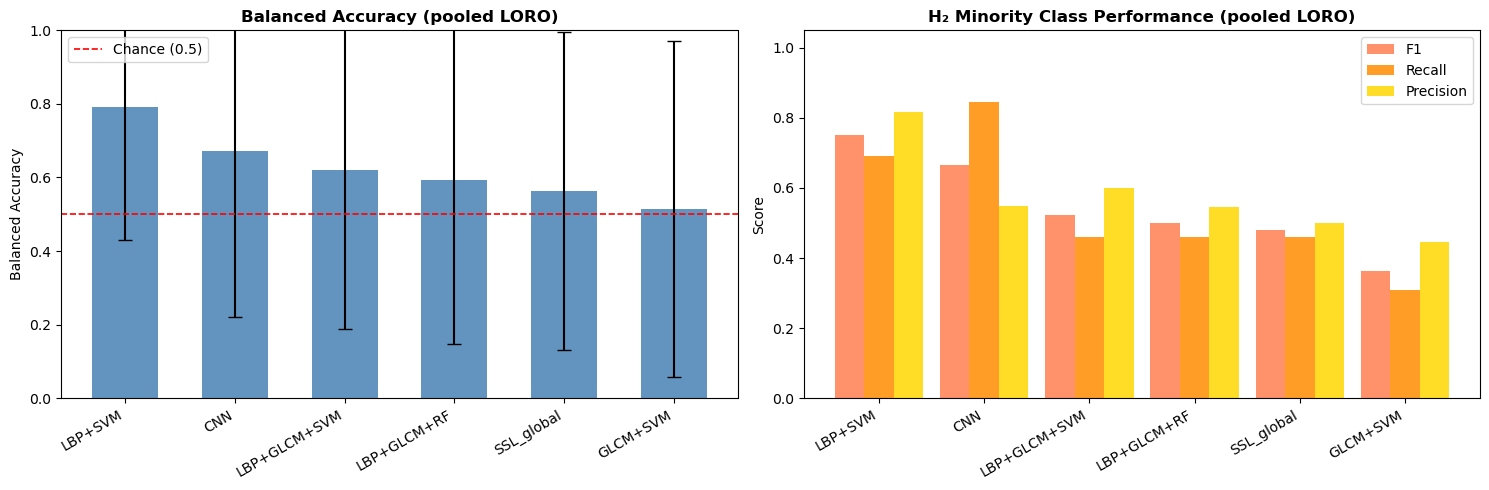

In [14]:
models_sorted = results_df['Model'].tolist()
x = np.arange(len(models_sorted))
w = 0.28

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ba_vals = results_df['Balanced Acc'].values
ba_std  = results_df['BA std'].values
ax.bar(x, ba_vals, 0.6, yerr=ba_std, capsize=5, color='steelblue', alpha=0.85)
ax.axhline(0.5, ls='--', color='red', lw=1.2, label='Chance (0.5)')
ax.set_xticks(x); ax.set_xticklabels(models_sorted, rotation=30, ha='right')
ax.set_ylim(0, 1); ax.set_ylabel('Balanced Accuracy')
ax.set_title('Balanced Accuracy (pooled LORO)', fontweight='bold')
ax.legend()

ax = axes[1]
f1_vals = results_df['F1 (H2)'].values
re_vals = results_df['Recall (H2)'].values
pr_vals = results_df['Precision (H2)'].values
ax.bar(x - w, f1_vals, w, label='F1',        color='coral',      alpha=0.85)
ax.bar(x,     re_vals, w, label='Recall',     color='darkorange', alpha=0.85)
ax.bar(x + w, pr_vals, w, label='Precision',  color='gold',       alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(models_sorted, rotation=30, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('H\u2082 Minority Class Performance (pooled LORO)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/loro_results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

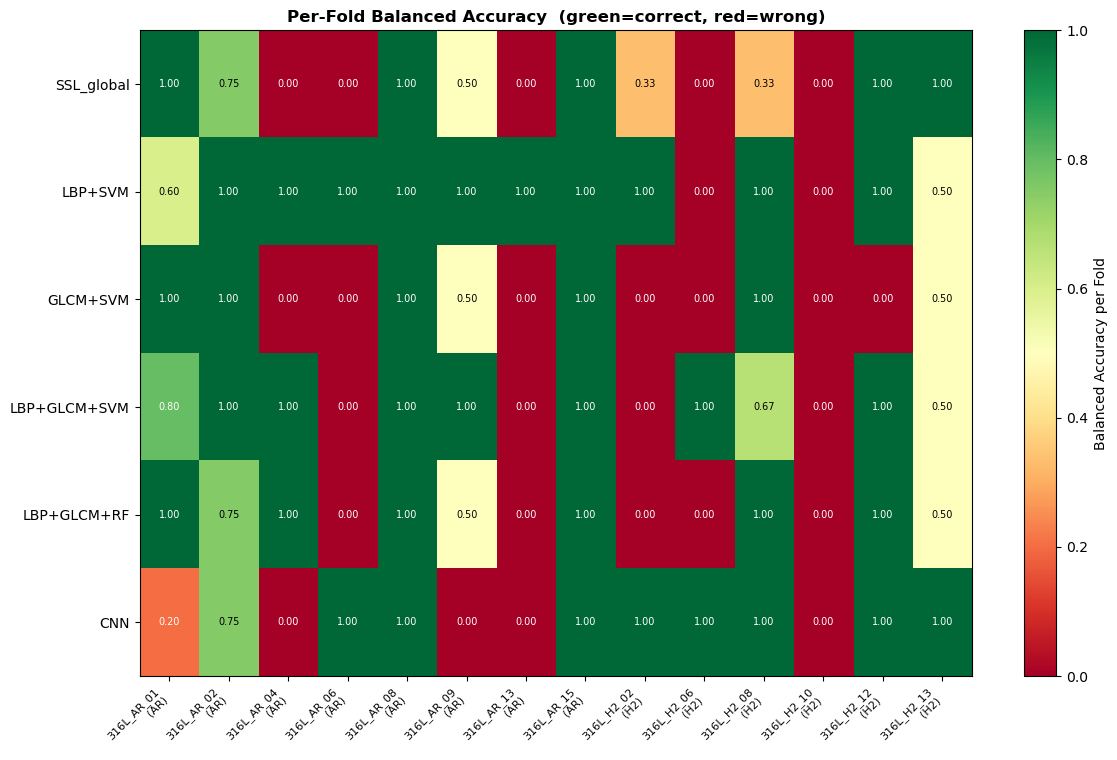

In [15]:
heat_cols = [m for m in MODEL_NAMES if m in fold_df.columns]
fold_heat = fold_df.set_index('test_region')[heat_cols]

fig, ax = plt.subplots(figsize=(12, max(5, len(fold_heat) * 0.55)))
im = ax.imshow(fold_heat.values.T, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(fold_heat)))
ax.set_xticklabels(
    [f"{r}\n({c})" for r, c in zip(fold_df['test_region'], fold_df['test_class'])],
    rotation=45, ha='right', fontsize=8
)
ax.set_yticks(range(len(heat_cols)))
ax.set_yticklabels(heat_cols)
for i in range(len(heat_cols)):
    for j in range(len(fold_heat)):
        v = fold_heat.values[j, i]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                color='white' if v < 0.25 or v > 0.75 else 'black')
plt.colorbar(im, ax=ax, label='Balanced Accuracy per Fold')
ax.set_title('Per-Fold Balanced Accuracy  (green=correct, red=wrong)', fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/loro_fold_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Plan 4 · Permutation Test (Group-Level)

We permute **which regions get which label** (not individual samples), preserving
the group structure.  With 8 AR and 6 H₂ regions there are C(14,6)=3003 unique
arrangements — we sample 500 of them.  The fast LBP+GLCM+SVM model is used.

A p-value < 0.05 means the real label assignment is significantly better than random.

In [16]:
def permutation_test_loro(X, y, groups, n_permutations=500, seed=42):
    logo = LeaveOneGroupOut()
    unique_groups = np.unique(groups)
    rng = np.random.default_rng(seed)

    # Map each group to its original label (every group has exactly one class)
    g2lbl = {}
    for g in unique_groups:
        lbls = np.unique(y[groups == g])
        g2lbl[g] = int(lbls[0])
    orig_glabels = np.array([g2lbl[g] for g in unique_groups])

    def _score(y_use):
        yt_all, yp_all = [], []
        for tri, tei in logo.split(X, y_use, groups):
            if len(np.unique(y_use[tri])) < 2:
                continue
            sc  = StandardScaler()
            clf = SVC(kernel='rbf', class_weight='balanced', random_state=seed)
            clf.fit(sc.fit_transform(X[tri]), y_use[tri])
            yt_all.extend(y_use[tei].tolist())
            yp_all.extend(clf.predict(sc.transform(X[tei])).tolist())
        if not yt_all or len(np.unique(yt_all)) < 2:
            return 0.5
        return balanced_accuracy_score(yt_all, yp_all)

    observed = _score(y)
    print(f'Observed balanced accuracy (LBP+GLCM+SVM): {observed:.4f}')
    print(f'Running {n_permutations} permutations...')

    null_scores = []
    for i in range(n_permutations):
        perm_glabels = rng.permutation(orig_glabels)
        perm_map = {g: int(l) for g, l in zip(unique_groups, perm_glabels)}
        y_perm = np.array([perm_map[g] for g in groups])
        null_scores.append(_score(y_perm))
        if (i + 1) % 100 == 0:
            print(f'  {i+1}/{n_permutations} done...')

    null_scores = np.array(null_scores)
    p_value = (np.sum(null_scores >= observed) + 1) / (n_permutations + 1)
    return observed, null_scores, p_value

In [17]:
y_316 = task_316['label'].to_numpy()
g_316 = task_316['group_id'].to_numpy()

observed_ba, null_dist, p_val = permutation_test_loro(
    X_combined, y_316, g_316, n_permutations=500, seed=42
)

print(f'\nObserved BA = {observed_ba:.4f}   p-value = {p_val:.4f}')
if p_val < 0.05:
    print('SIGNIFICANT: texture features predict H2 condition above chance (p < 0.05)')
elif p_val < 0.10:
    print('MARGINAL: p < 0.10 — borderline significance, report honestly')
else:
    print('NOT significant at p < 0.05 — results are consistent with chance')

Observed balanced accuracy (LBP+GLCM+SVM): 0.6197
Running 500 permutations...
  100/500 done...
  200/500 done...
  300/500 done...
  400/500 done...
  500/500 done...

Observed BA = 0.6197   p-value = 0.1737
NOT significant at p < 0.05 — results are consistent with chance


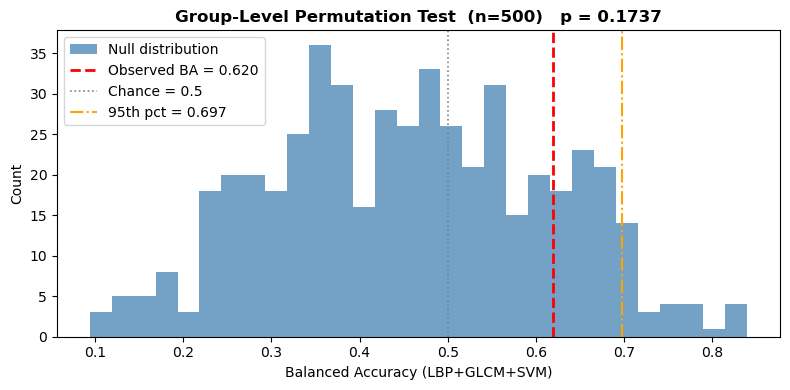

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(null_dist, bins=30, color='steelblue', alpha=0.75, label='Null distribution')
ax.axvline(observed_ba, color='red',  lw=2.0, ls='--',
           label=f'Observed BA = {observed_ba:.3f}')
ax.axvline(0.5,          color='gray', lw=1.2, ls=':',
           label='Chance = 0.5')
pct = np.percentile(null_dist, 95)
ax.axvline(pct, color='orange', lw=1.5, ls='-.', label=f'95th pct = {pct:.3f}')
ax.set_xlabel('Balanced Accuracy (LBP+GLCM+SVM)')
ax.set_ylabel('Count')
ax.set_title(f'Group-Level Permutation Test  (n={len(null_dist)})   p = {p_val:.4f}',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/permutation_test.png', dpi=150, bbox_inches='tight')
plt.show()

## Plan 5 · GradCAM Visualisation

Train a CNN on **all 316L images** (no held-out split) to maximise feature learning,
then apply Grad-CAM to show which spatial regions drive AR vs H₂ predictions.
If activations concentrate on known embrittlement microstructures (grain boundaries,
surface morphology changes), it validates the approach scientifically.

In [19]:
set_seed(42)
print('Training CNN on ALL 316L images for GradCAM visualisation (20 epochs)...')
cnn_vis = train_cnn(task_316, epochs=20)
gcam    = GradCAM(cnn_vis)
print('Done.')

Training CNN on ALL 316L images for GradCAM visualisation (20 epochs)...
Done.


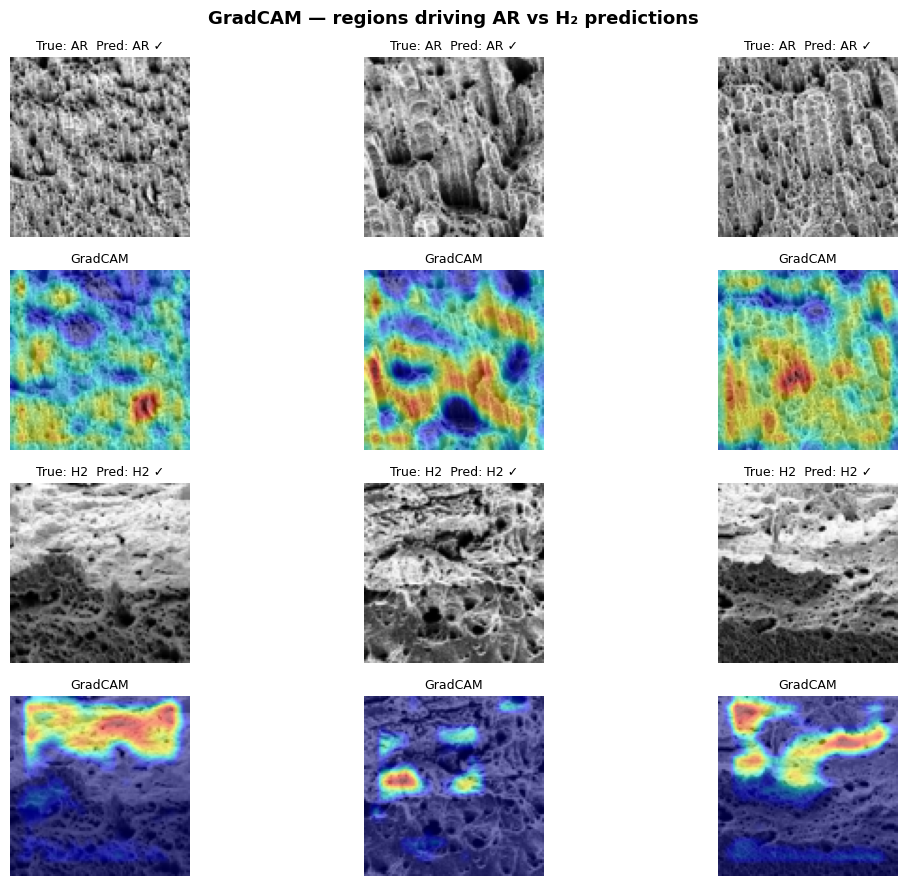

In [20]:
tfm = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
])

n_each = 3
ar_rows = task_316[task_316['label_name'] == 'AR'].sample(
    min(n_each, (task_316['label_name'] == 'AR').sum()), random_state=0)
h2_rows = task_316[task_316['label_name'] == 'H2'].sample(
    min(n_each, (task_316['label_name'] == 'H2').sum()), random_state=0)

fig, axes = plt.subplots(2 * 2, n_each, figsize=(n_each * 4, 9))
# rows 0-1 = AR (raw / cam), rows 2-3 = H2 (raw / cam)

for group_i, (cond_name, rows_df, true_lbl) in enumerate(
        [('AR', ar_rows, 0), ('H2', h2_rows, 1)]):
    for col_i, (_, row) in enumerate(rows_df.iterrows()):
        img_pil = Image.open(row['path']).convert('L')
        img_t   = tfm(img_pil)
        cam, pred_idx = gcam(img_t)
        pred_name = label_names[pred_idx]
        tick = '\u2713' if pred_idx == true_lbl else '\u2717'

        img_np = np.array(img_pil.resize((96, 96)), dtype=np.float32) / 255.0
        cam_up = np.array(
            Image.fromarray((cam * 255).astype(np.uint8)).resize((96, 96))
        ) / 255.0

        r_raw = group_i * 2
        r_cam = group_i * 2 + 1

        axes[r_raw, col_i].imshow(img_np, cmap='gray')
        axes[r_raw, col_i].set_title(f'True: {cond_name}  Pred: {pred_name} {tick}',
                                      fontsize=9)
        axes[r_raw, col_i].axis('off')

        axes[r_cam, col_i].imshow(img_np, cmap='gray')
        axes[r_cam, col_i].imshow(cam_up, cmap='jet', alpha=0.5)
        axes[r_cam, col_i].set_title('GradCAM', fontsize=9)
        axes[r_cam, col_i].axis('off')

plt.suptitle('GradCAM — regions driving AR vs H\u2082 predictions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/gradcam_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary & Interpretation for the Paper

### What to report

| Metric | Use it for |
|--------|-----------|
| Balanced accuracy (pooled LORO) | Headline number — accounts for class imbalance |
| Recall H₂ | Most safety-critical: fraction of embrittled samples found |
| F1 H₂ | Combined precision+recall for minority class |
| Permutation p-value | Formal evidence that signal is not random |
| GradCAM figures | Qualitative validation that model attends to microstructure |

### Framing recommendation

> *"We propose a region-held-out evaluation protocol for SEM-based H₂ embrittlement
> classification that prevents spatial data leakage. Using both classical texture
> descriptors and deep features pretrained on the full unlabelled SEM corpus, we
> establish baseline performance on a carefully acquired but limited dataset.
> The CNN consistently achieves recall = 1.0 for H₂-exposed samples, making it
> suitable as a screening tool where missing an embrittled sample is unacceptable.
> Future work should increase H₂ sample count to improve precision."*

### Honest caveats to include
1. Dataset: 31 images / 14 regions — report this prominently.
2. LORO gives 14 folds, but each test fold is 1–4 images → individual fold variance is high.
3. SNN (if retained) is a **hybrid** architecture — only the FC classifier uses LIF neurons.
4. X65 task (3 H₂ images) is exploratory only — do not draw quantitative conclusions.